# 🌞 Quick Look: Observation & Nowcast on a Map

This notebook opens **one observation file** and **one nowcast file**, and plots them on a map.

Use it to verify that the data looks sensible before building the full validation pipeline.

In [119]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from pathlib import Path

# Directories where the data lives
OBS_DIR = Path("/dmidata/projects/energivejr/satellite_data")
NWC_DIR = Path("/dmidata/projects/energivejr/nowcasts")

In [135]:
## 1. Open a single Observation file

# Observation files are named like: `NetCDF4_sds_2026-02-26T12_00_00Z.nc`

# We open it with xr.open_dataset() and inspect the contents.

# Open a single observation file
obs_file = 'NetCDF4_sds_2026-02-26T12_00_00Z.nc'
obs_ds = xr.open_dataset(OBS_DIR / obs_file, engine="h5netcdf")


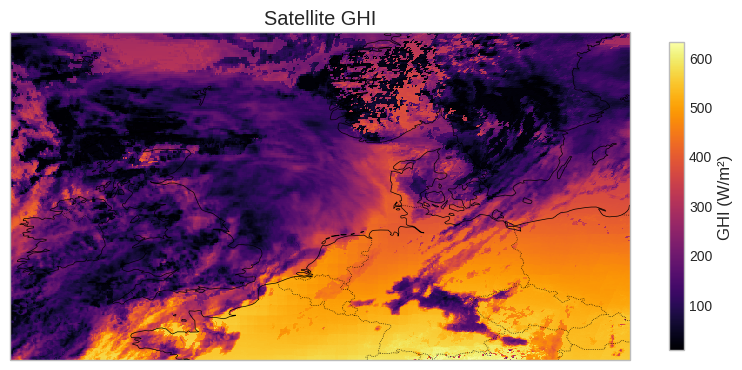

In [136]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

obs_ds.sds.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='inferno', cbar_kwargs={'label': 'GHI (W/m²)', 'shrink': 0.5})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title(f"Satellite GHI")
plt.show()


In [142]:
## 2. Open a single Nowcast file

#Nowcast files are named like: `SolarNowcast_202602261200.nc`

#Same idea — open one file and inspect it.

nwc_file = 'SolarNowcast_202602261200.nc'
nwc_ds = xr.open_dataset(NWC_DIR / nwc_file, engine="h5netcdf")

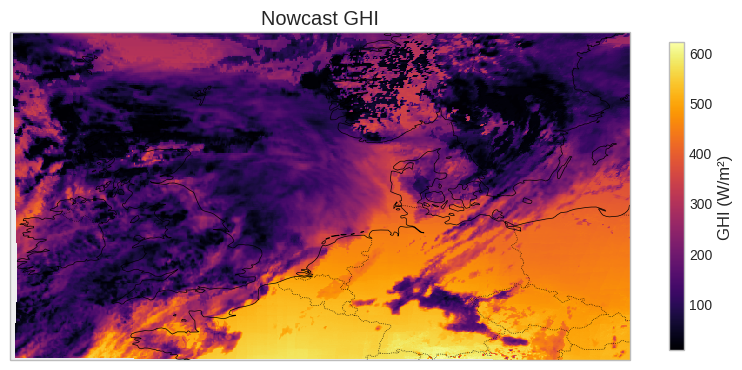

In [143]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

nwc_ds.probabilistic_advection.isel(time=0).plot(ax=ax, transform=ccrs.PlateCarree(), cmap='inferno', cbar_kwargs={'label': 'GHI (W/m²)', 'shrink': 0.5})

ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':')
ax.set_title(f"Nowcast GHI")
plt.show()

In [144]:
obs_ds

<xarray.Dataset> Size: 2MB
Dimensions:  (time: 1, y: 368, x: 713)
Coordinates:
  * time     (time) datetime64[ns] 8B 2026-02-26T12:00:00
  * y        (y) float64 3kB 63.48 63.43 63.39 63.35 ... 47.4 47.36 47.32 47.27
  * x        (x) float64 6kB -10.73 -10.69 -10.64 -10.6 ... 19.89 19.94 19.98
Data variables:
    crs      |S1 1B ...
    sds      (time, y, x) float32 1MB ...
    sds_cs   (time, y, x) float32 1MB ...
Attributes: (12/25)
    Conventions:                                              CF-1.6
    title:                                                    Cloud Physical ...
    institution:                                              Royal Netherlan...
    source:                                                   CPP_6.1
    history:                                                  Created by ADAG...
    references:                                               http://msgcpp.k...
    ...                                                       ...
    source_surface_emissivity:                                CIMMS
    subsatellite_longitude_nominal:                           0.0
    subsatellite_longitude_actual:                            0.20015523
    subsatellite_latitude_actual:                             -4.3989873
    adaguc_wcs_destgridspec:                                  width=713&heigh...
    software:                                                 ADAGUC WCS Serv...

In [145]:
nwc_ds

<xarray.Dataset> Size: 25MB
Dimensions:                  (ensemble: 1, time: 24, lat: 368, lon: 713)
Coordinates:
  * ensemble                 (ensemble) int64 8B 0
  * time                     (time) datetime64[ns] 192B 2026-02-26T12:15:00 ....
  * lat                      (lat) float64 3kB 63.48 63.43 63.39 ... 47.32 47.27
  * lon                      (lon) float64 6kB -10.73 -10.69 ... 19.94 19.98
Data variables:
    probabilistic_advection  (ensemble, time, lat, lon) float32 25MB ...
Attributes:
    description:    Simple Probabilistic Advection solar forecast using KNMI ...
    history:        Created 2026-02-26 12:24:00 UTC
    model_version:  0.3.0